# KNN 이진분류
- 오렌지, 그레이프후루츠 2진분류

# Basic setting

### Library

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical

### Random state, Target

In [41]:
SEED = 42
TARGET = 'name'

# Data Collection

### Load data from Url

In [42]:
citrus_link = 'https://raw.githubusercontent.com/devdio/flyai_datasets/main/citrus.csv'
df = pd.read_csv(citrus_link)
df.shape

(10000, 6)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB


In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
diameter,10000.0,9.975685,1.947844,2.96,8.46,9.980,11.4800,16.45
weight,10000.0,175.050792,29.212119,86.76,152.22,174.985,197.7225,261.51
red,10000.0,153.847800,10.432954,115.00,147.00,154.000,161.0000,192.00
green,10000.0,76.010600,11.708433,31.00,68.00,76.000,84.0000,116.00
blue,10000.0,11.363200,9.061275,2.00,2.00,10.000,17.0000,56.00


### Data visualization

<Axes: xlabel='name'>

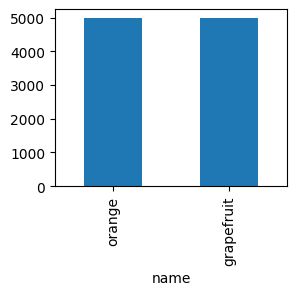

In [45]:
df['name'].value_counts().plot(kind='bar', figsize=(3, 2.3) )

# Data preprocessing

### Missing data - Null

In [46]:
# Handle missing values in numeric columns by filling with mean
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        print(f"Filling missing values in numeric column '{col}' with mean.")
        df[col].fillna(df[col].mean(), inplace=True)

# Handle missing values in categorical columns by filling with mode
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        print(f"Filling missing values in categorical column '{col}' with mode.")
        df[col].fillna(df[col].mode()[0], inplace=True)

### Encode categorical variables

In [47]:
# Convert categorical columns to numerical using Label Encoding
for col in categorical_cols:
  print(f"Encoding categorical column '{col}'.")

  le = LabelEncoder()
  # Convert to string before encoding
  df[col] = le.fit_transform(df[col].astype(str))

print("Missing values after preprocessing:")
print(df.isnull().sum())

Encoding categorical column 'name'.
Missing values after preprocessing:
name        0
diameter    0
weight      0
red         0
green       0
blue        0
dtype: int64


### Duplication

In [48]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]
print(f"Removed {initial_rows - final_rows} duplicate rows.")

Removed 0 duplicate rows.


# Data preparation

### Split: train and test

In [49]:
train, test = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df[TARGET])

train.shape, test.shape

((8000, 6), (2000, 6))

### Split: features and target

In [50]:
X_train = train.drop(TARGET, axis=1)
y_train = train[TARGET]
X_test = test.drop(TARGET, axis=1)
y_test = test[TARGET]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8000, 5), (8000,), (2000, 5), (2000,))

### Scaling

In [51]:
rs = RobustScaler()
X_train_s = rs.fit_transform(X_train)
X_test_s = rs.transform(test.drop(TARGET, axis=1))

X_train_s.shape

(8000, 5)

In [52]:
y_train = to_categorical(y_train, num_classes=3)

# Model

### Create model

In [53]:
from keras import layers

input_shape = X_train_s.shape[1:]

model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=input_shape),
    layers.Dense(8, activation='relu'),
    layers.Dense(3, activation='softmax')
    # eng -> Sigmoid when you executes the multi-classification
])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 16)                  │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 259 (1.01 KB)

 Trainable params: 259 (1.01 KB)

 Non-trainable params: 0 (0.00 B)

### Compile

In [54]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

### History

In [55]:
EPOCH = 100
BATCH_SIZE = 16
history = model.fit(
    X_train_s, y_train,
    epochs=EPOCH,
    batch_size=BATCH_SIZE,
    validation_split=0.2
)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8403 - loss: 0.5739 - val_accuracy: 0.9225 - val_loss: 0.1875
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9262 - loss: 0.1937 - val_accuracy: 0.9200 - val_loss: 0.1843
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9287 - loss: 0.1838 - val_accuracy: 0.9225 - val_loss: 0.1768
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9237 - loss: 0.1883 - val_accuracy: 0.9219 - val_loss: 0.1760
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9270 - loss: 0.1806 - val_accuracy: 0.9262 - val_loss: 0.1775
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9348 - loss: 0.1709 - val_accuracy: 0.9237 - val_loss: 0.1788
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9192 - loss: 0.1887 - val_accuracy: 0.9237 - val_loss: 0.1724
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9358 - loss: 0.1710 - val_accu

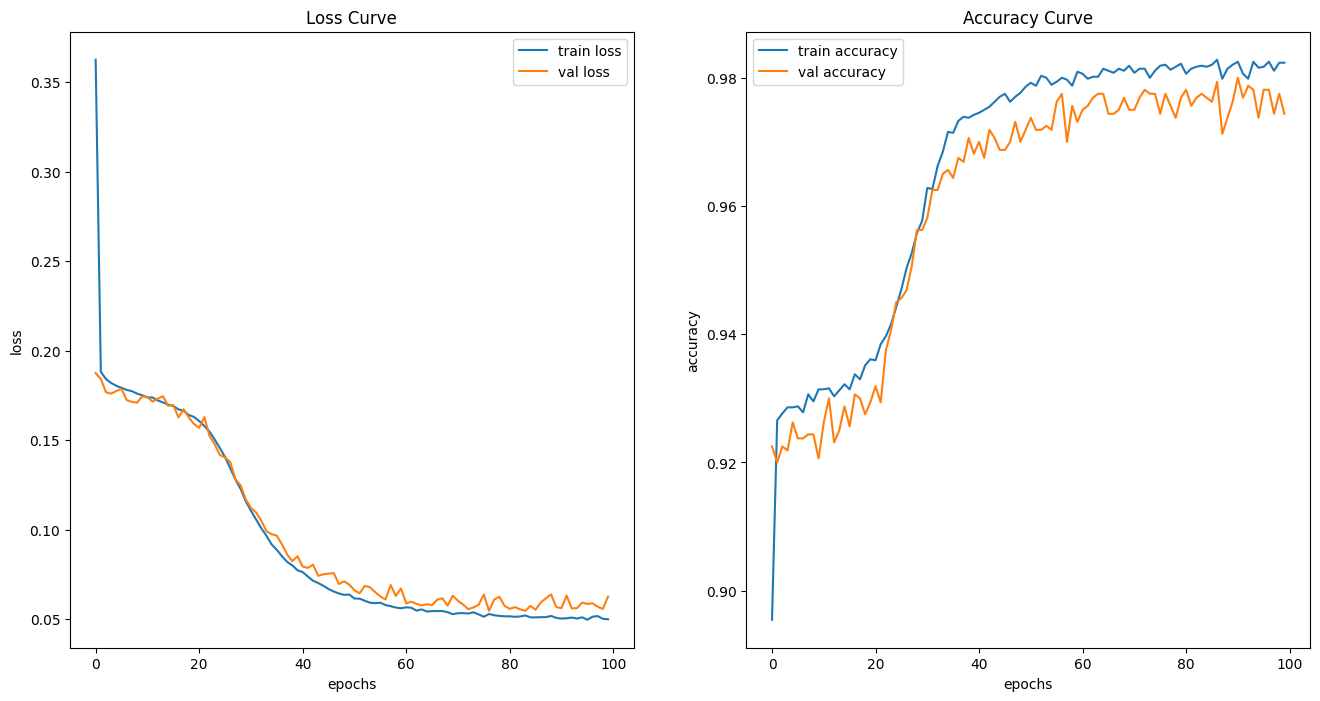

In [56]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure(figsize=(16, 8))
  plt.subplot(1, 2, 1)
  plt.xlabel('epochs')
  plt.ylabel('loss')
  plt.plot(hist['epoch'], hist['loss'], label='train loss')
  plt.plot(hist['epoch'], hist['val_loss'], label='val loss')
  plt.title('Loss Curve')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.xlabel('epochs')
  plt.ylabel('accuracy')
  plt.plot(hist['epoch'], hist['accuracy'], label='train accuracy')
  plt.plot(hist['epoch'], hist['val_accuracy'], label='val accuracy')
  plt.title('Accuracy Curve')
  plt.legend()
  plt.show()

plot_history(history)

# Estimate

### Prediction of test data

In [57]:
y_pred = model.predict(X_test_s)
y_pred.shape

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


(2000, 3)

In [58]:
import numpy as np

y_pred = np.argmax(y_pred, axis=1)
y_pred

array([0, 1, 0, ..., 1, 1, 1])

### Show perfomance of model

accuracy: 0.9785
recall: 0.9784999999999999
precision: 0.9785579055065663
f1 : 0.9784993496053256


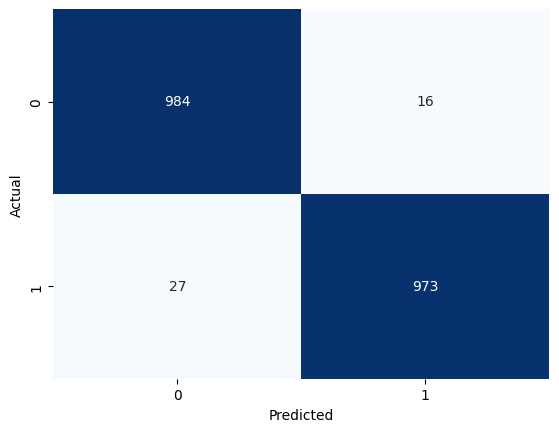

In [59]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred, ave='binary'):
  print('accuracy:', accuracy_score(y_test, y_pred))
  print('recall:', recall_score(y_test, y_pred, average=ave))
  print('precision:', precision_score(y_test, y_pred, average=ave))
  print('f1 :', f1_score(y_test, y_pred, average=ave))

  clm = confusion_matrix(y_test, y_pred)
  s = sns.heatmap(clm, annot=True, cmap='Blues', fmt='d', cbar=False)
  s.set(xlabel='Predicted', ylabel='Actual')

print_metrics(y_test, y_pred, ave='macro')